In [1]:
import frc
import numpy as np
import matplotlib.pyplot as plt
from tifffile import imread
from pathlib import Path

DIPlib -- a quantitative image analysis library
Version 3.5.0 (Jun 18 2024)
For more information see https://diplib.org


In [2]:
def crop_center(img,crop_size):

    if type(crop_size) == tuple:
        crop_x,crop_y = crop_size
    elif type(crop_size) == int:
        crop_x = crop_size
        crop_y = crop_size
    
    y,x = img.shape[-2::]
    startx = x//2-(crop_x//2)
    starty = y//2-(crop_y//2)        

    return img[...,starty:starty+crop_y,startx:startx+crop_x]

In [7]:
import os

# Folder containing the image stacks
img_path = r'\\storage3.ad.scilifelab.se\testalab\Guillaume\01_Projects\DL_monalisa\_paper\Denoising_charac\Model_comp\all_in_one_normalized.tif'
stack = imread(img_path)

sup = stack[:,[0,1,3,4]]
unsup = stack[:,[0,2,5,6]]
print(sup.shape,unsup.shape)

sup_list = ["GT","CARE","HDNsup","RCAN"]
unsup_list = ["GT","HDNunsup","SN2N","N2V"]

(3, 4, 1200, 1200) (3, 4, 1200, 1200)


In [8]:
frc_curves_sup = []
for img_idx,img in enumerate(sup):
    gt = img[0]
    gt = frc.util.apply_tukey(gt)
        
    frc_curves = []
    
    for nn_idx in range(len(sup_list)):
        pred = img[nn_idx]
        pred = pred - np.min(pred)
        pred = frc.util.apply_tukey(pred)
        frc_curve,_,_ = frc.one_frc(pred)
        frc_curve = (frc_curve - np.min(frc_curve)) / (np.max(frc_curve) - np.min(frc_curve))
        frc_curves.append(frc_curve)
        
    frc_curves_sup.append(np.stack(frc_curves))

frc_curves_sup = np.stack(frc_curves_sup)
avg_frc_curves_sup = np.mean(frc_curves_sup,axis=0)
std_frc_curves_sup = np.std(frc_curves_sup, axis=0)

frc_curves_unsup = []
for img_idx,img in enumerate(unsup):
    gt = img[0]
    gt = frc.util.apply_tukey(gt)
        
    frc_curves = []
    
    for nn_idx in range(len(unsup_list)):
        pred = img[nn_idx]
        pred = pred - np.min(pred)
        pred = frc.util.apply_tukey(pred)
        frc_curve,_,_ = frc.one_frc(pred)
        frc_curve = (frc_curve - np.min(frc_curve)) / (np.max(frc_curve) - np.min(frc_curve))
        frc_curves.append(frc_curve)
        
    frc_curves_unsup.append(np.stack(frc_curves))

frc_curves_unsup = np.stack(frc_curves_unsup)
avg_frc_curves_unsup = np.mean(frc_curves_unsup,axis=0)
std_frc_curves_unsup = np.std(frc_curves_unsup, axis=0)


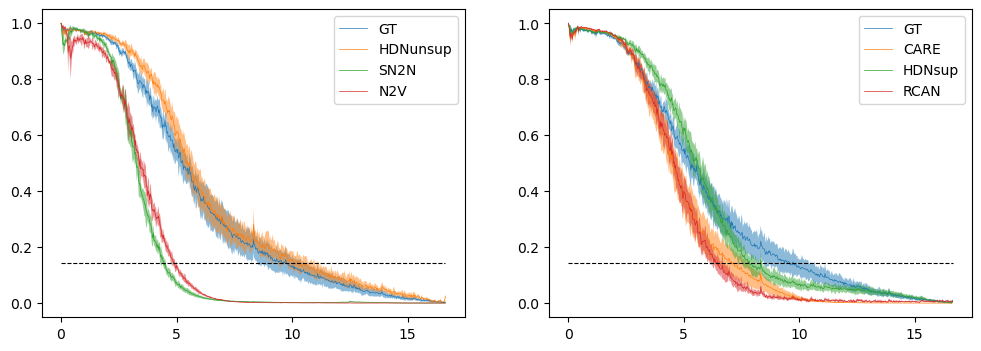

In [51]:
# Plot 1frc 
scale = 1/30*1e3
img_size = pred.shape

# colors = ["blue",'orange', 'green', 'red']

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
for i,name in enumerate(unsup_list):
    frc_curve = avg_frc_curves_unsup[i]
    std_curve = std_frc_curves_unsup[i]
    xs_pix = np.arange(len(frc_curve)) / img_size[0]
    xs_nm_freq = xs_pix * scale

    axs[0].plot(xs_nm_freq, frc_curve,label=name,linewidth=0.5)
    axs[0].fill_between(xs_nm_freq, frc_curve - std_curve, frc_curve + std_curve, alpha=0.5)

    frc_res, res_y, thres = frc.frc_res(xs_nm_freq, frc_curve, img_size)
    # print(frc_res)
axs[0].plot(xs_nm_freq, thres(xs_nm_freq),'k--',linewidth=0.8)
axs[0].legend()
axs[0].set_xticks([0,5,10,15])

# axs[0].xticks([0,5,10,15])
for i,name in enumerate(sup_list):
    frc_curve = avg_frc_curves_sup[i]
    std_curve = std_frc_curves_sup[i]
    xs_pix = np.arange(len(frc_curve)) / img_size[0]
    xs_nm_freq = xs_pix * scale

    axs[1].plot(xs_nm_freq, frc_curve,label=name,linewidth=0.5)
    axs[1].fill_between(xs_nm_freq, frc_curve - std_curve, frc_curve + std_curve ,alpha=0.5)

    frc_res, res_y, thres = frc.frc_res(xs_nm_freq, frc_curve, img_size)
    # print(frc_res)
axs[1].plot(xs_nm_freq, thres(xs_nm_freq),'k--',linewidth=0.8)
axs[1].legend()
axs[1].set_xticks([0,5,10,15])

plt.show()

In [53]:
save_folder = Path(r"\\storage3.ad.scilifelab.se\testalab\Guillaume\01_Projects\DL_monalisa\_paper\Denoising_charac\Model_comp")

fig.savefig(save_folder/"1FRC.svg", format="svg", bbox_inches='tight')